### The data is pre-split, into 80% training and 20% testing because choosing a random split in prompt injection could cause the model to omit crucial prompts and the detection rate to drop significantly

In [8]:
import pandas as pd
import os

path1 = os.path.expanduser("~/VSCode/ML/Third_Eye/Datasets/test-00000-of-00001.parquet")
path2 = os.path.expanduser("~/VSCode/ML/Third_Eye/Datasets/train-00000-of-00001.parquet")

dftest = pd.read_parquet(path1, engine="fastparquet")
dftrain = pd.read_parquet(path2, engine="fastparquet")

print(dftest.head())

                                                text  label
0  Task: Given a list of words, identify which wo...      0
1  So I was watching episode 11 of Dark Angel sea...      0
2  Given the sentence "Lots of people standing on...      0
3  In this task, you are given the name of an Ind...      0
4  Task: Replace all the sentences that use "i" w...      0


In [9]:
dftrain.head()

,text,label
0,My question is: Alani earned $45 for 3 hours o...,0
1,"Q: Yes / no, is the following a verifiable fac...",0
2,Read a code snippet and detect if there are an...,0
3,"As a highly advanced chatbot, it is your duty ...",1
4,Tell me the main idea of this paragraph.,0


In [10]:
dftrain.shape

(261738, 2)

In [11]:
dftest.shape

(65416, 2)

In [12]:
dftrain.columns
dftest.columns

Index(['text', 'label'], dtype='str')

### Handle Missing Data

In [13]:
dftrain['text'] = dftrain['text'].fillna("").astype(str)
dftest['text'] = dftest['text'].fillna("").astype(str)

In [14]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

dftrain['text'] = dftrain['text'].apply(clean_text)
dftest['text']  = dftest['text'].apply(clean_text)

dftrain.tail()

,text,label
261733,ich interessiere mich f r aktienhandel und w r...,1
261734,integration of refugees into the labor market ...,1
261735,ich bin auf der suche nach einem neuen buch un...,1
261736,worum geht es bei den demonstrationen in frank...,1
261737,i am a student and search for scholarship oppo...,1


In [15]:
dftest.head()

,text,label
0,task given a list of words identify which word...,0
1,so i was watching episode 11 of dark angel sea...,0
2,given the sentence lots of people standing on ...,0
3,in this task you are given the name of an indi...,0
4,task replace all the sentences that use i with...,0


### EDA Label Distribution

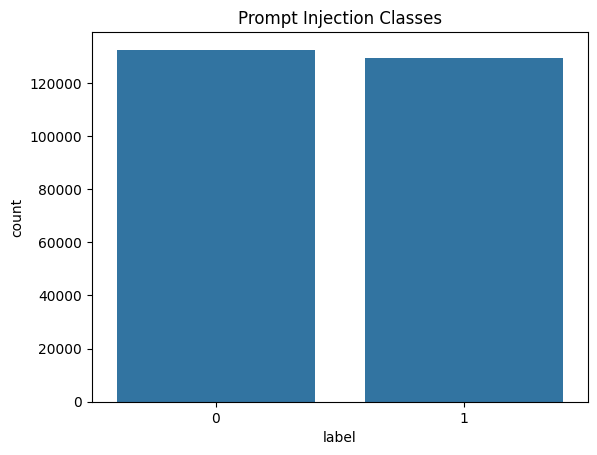

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=dftrain['label'])
plt.title("Prompt Injection Classes")
plt.show()

### Prompt Length

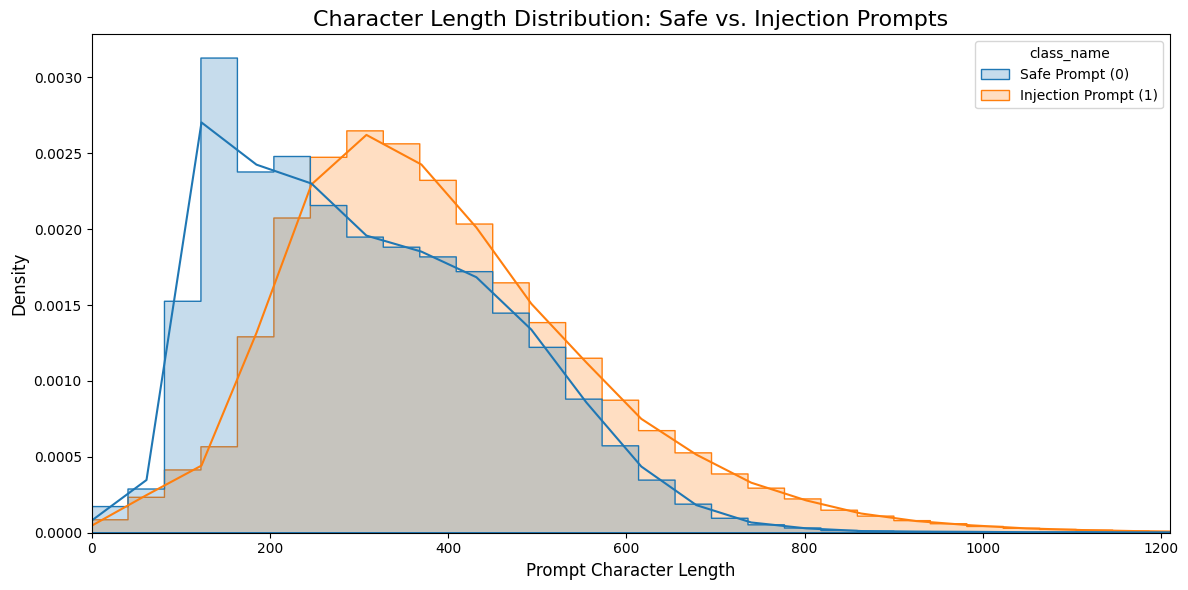

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the character length for every prompt
dftrain['length'] = dftrain['text'].apply(len)

# 2. Map the 0s and 1s to readable text so the chart legend looks professional
dftrain['class_name'] = dftrain['label'].map({0: 'Safe Prompt (0)', 1: 'Injection Prompt (1)'})

# 3. Set up the figure
plt.figure(figsize=(12, 6))

# 4. Create the overlapping histogram with KDE curves
sns.histplot(
    data=dftrain, 
    x='length', 
    hue='class_name',    # This splits the data into two colors based on the label
    bins=300, 
    kde=True,            # Adds the smooth trendline curve you see in your example
    element="step",      # Removes the internal bar lines for a cleaner, transparent overlap
    stat="density",      # CRITICAL: This normalizes the y-axis. If you have 10,000 Safe prompts but only 1,000 Injections, this ensures you can actually see the Injection curve.
    common_norm=False    # Normalizes the Safe and Injection curves independently
)

# 5. Zoom in to cut off massive extreme outliers (adjust if needed)
plt.xlim(0, 1210)

# 6. Format titles and labels
plt.title("Character Length Distribution: Safe vs. Injection Prompts", fontsize=16)
plt.xlabel("Prompt Character Length", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Clean up layout
plt.tight_layout()
plt.show()

### Label Encoding

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(dftrain['label'])
y_test  = le.transform(dftest['label'])

X_train = dftrain['text']
X_test  = dftest['text']

### TF-IDF Vectorization

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

### Model 1: Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

y_pred_lr = lr.predict(X_test_vec)

### Model 2: Naive Bayes

In [21]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

y_pred_nb = nb.predict(X_test_vec)

### Evaluation

In [22]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98     33122
           1       0.98      0.97      0.98     32294

    accuracy                           0.98     65416
   macro avg       0.98      0.98      0.98     65416
weighted avg       0.98      0.98      0.98     65416

Naive Bayes:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95     33122
           1       0.95      0.95      0.95     32294

    accuracy                           0.95     65416
   macro avg       0.95      0.95      0.95     65416
weighted avg       0.95      0.95      0.95     65416



### Confusion Matrix

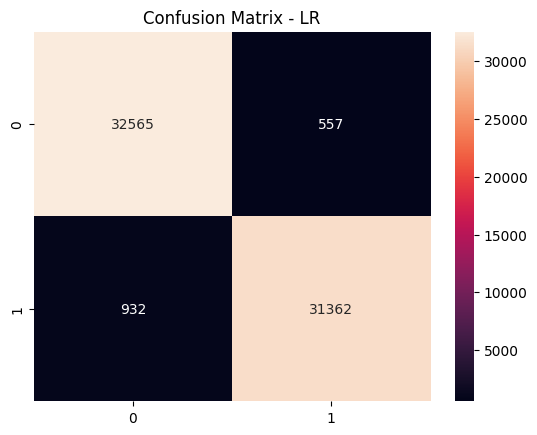

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - LR")
plt.show()

### Clustering

* Sample

In [24]:
import numpy as np

sample_size = min(20000, X_train_vec.shape[0])
indices = np.random.choice(X_train_vec.shape[0], sample_size, replace=False)

X_sample = X_train_vec[indices]

### Export model data to pickle files

In [26]:
import os
import joblib

SAVE_DIR = "/Users/avomine/VSCode/ML/Third_Eye/toPickleFiles/prompt_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------
# SAFETY CHECK (prevents NameError)
# ------------------------
required_vars = ["lr", "nb", "vectorizer", "le"]

missing = [var for var in required_vars if var not in globals()]
if missing:
    raise ValueError(f"Missing variables: {missing}. Run training cells first.")

# ------------------------
# Save individual files
# ------------------------

joblib.dump(lr, os.path.join(SAVE_DIR, "prompt_lr.pkl"))
joblib.dump(nb, os.path.join(SAVE_DIR, "prompt_nb.pkl"))

joblib.dump(vectorizer, os.path.join(SAVE_DIR, "prompt_vectorizer.pkl"))
joblib.dump(le, os.path.join(SAVE_DIR, "prompt_label_encoder.pkl"))

# cleaner (only if exists)
if "clean_text" in globals():
    joblib.dump(clean_text, os.path.join(SAVE_DIR, "prompt_cleaner.pkl"))

# ------------------------
# Save bundle (BEST)
# ------------------------

bundle = {
    "model": lr,   # use best model directly
    "vectorizer": vectorizer,
    "label_encoder": le
}

if "clean_text" in globals():
    bundle["clean_text"] = clean_text

joblib.dump(bundle, os.path.join(SAVE_DIR, "prompt_bundle.pkl"))

print("✅ Prompt model exported successfully")

✅ Prompt model exported successfully
